# A simple Localization Problem

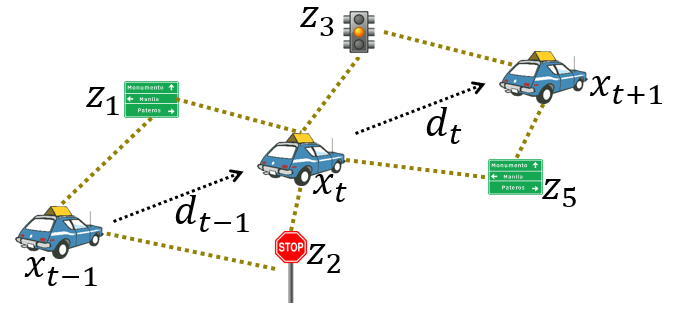

### Given
1. Map: Global position of landmarks as $z_i$
1. Motion model of the robot, e.g. $x_{t+1} = x_t + d_t + \epsilon_t$, $\epsilon_t \sim \mathcal{N}(0, R_t)$.
1. Observations model as the bearing of the landmarks $f_{i,t} = H(z_i  - x_t) + \eta_{i,t}$, $\eta_{i,t} \sim \mathcal{N}(0, Q_t)$.
1. Local observations at each time step for some of the landmarks $f_{i,t}$.
1. Initial Location $x_0 \sim \mathcal{N}(\mu_0, \Sigma_0)$.

### Find

The position and orientation of the robot, $x_t$



In [1]:
!pip install -q requests scipy ipywidgets svgpath2mpl
from scipy.stats import multivariate_normal
import requests
from io import BytesIO
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from svgpath2mpl import parse_path

# 🚗
mplcar = parse_path('M 9880,3580 C 8932,3481 8224,2669 8263,1725 8305,731 9137,-38 10125,3 c 383,16 740,147 1040,381 108,86 275,261 357,376 375,530 432,1228 148,1815 -254,525 -756,898 -1330,990 -120,19 -349,26 -460,15 z m 316,-951 c 276,-48 513,-230 629,-483 59,-127 78,-228 72,-386 -3,-102 -10,-152 -27,-205 -53,-166 -156,-319 -282,-420 -78,-62 -221,-135 -313,-161 -90,-25 -293,-30 -388,-10 -332,68 -595,333 -662,665 -23,110 -16,295 14,395 92,308 341,539 651,601 81,16 227,18 306,4 z m -7048,950 c -704,-68 -1305,-547 -1528,-1217 -64,-193 -81,-291 -87,-512 -9,-326 39,-556 172,-836 226,-471 668,-831 1176,-958 917,-230 1850,283 2144,1179 98,296 116,613 54,919 -180,893 -1021,1513 -1931,1425 z m 402,-969 c 41,-12 113,-41 160,-65 168,-88 288,-211 370,-380 59,-123 80,-200 87,-330 23,-423 -282,-803 -704,-876 -38,-7 -117,-10 -187,-7 -105,4 -135,10 -223,40 -223,76 -383,215 -488,423 -65,130 -87,222 -88,375 -2,220 60,387 207,564 109,129 312,244 488,276 89,15 292,5 378,-20 z M 6736,8049 C 5644,7975 4679,7579 3820,6851 c -188,-159 -476,-443 -656,-646 -119,-133 -241,-282 -414,-503 -296,-377 -501,-556 -734,-641 -47,-16 -187,-53 -313,-81 -340,-75 -481,-121 -698,-224 C 776,4646 637,4548 488,4392 243,4134 94,3779 36,3310 -1,3012 -11,2609 16,2432 77,2019 332,1682 739,1478 l 95,-48 181,0 c 100,0 184,2 187,5 3,3 2,26 -3,50 -22,118 -30,309 -20,448 25,314 83,530 216,802 115,237 242,411 431,595 330,320 725,516 1184,587 158,24 473,24 625,0 650,-106 1178,-456 1521,-1010 240,-386 352,-889 299,-1332 -8,-66 -15,-126 -15,-132 0,-10 257,-13 1250,-13 688,0 1250,1 1250,3 0,1 -7,52 -15,112 -17,128 -19,351 -5,480 65,580 362,1110 823,1467 644,498 1517,587 2252,229 655,-319 1099,-938 1191,-1661 13,-107 15,-174 10,-325 -4,-104 -9,-208 -13,-230 l -6,-40 54,46 c 30,25 88,85 130,132 326,367 480,883 429,1432 -29,304 -122,576 -277,809 -74,111 -222,271 -308,332 -53,37 -55,41 -51,77 16,141 -54,476 -180,861 -75,230 -102,295 -198,481 -208,406 -517,826 -979,1333 -181,199 -320,298 -635,456 -711,356 -1636,569 -2722,626 -221,11 -528,11 -704,-1 z m 169,-832 c 205,-58 380,-204 470,-391 67,-141 68,-150 72,-586 5,-424 -7,-720 -32,-840 -31,-150 -103,-259 -195,-299 l -49,-21 -1563,2 -1563,3 -57,23 c -62,25 -150,98 -174,144 -29,56 -36,130 -19,210 30,143 125,307 309,532 602,735 1130,1102 1737,1207 196,33 265,37 644,35 303,-2 370,-5 420,-19 z m 2100,-101 c 179,-44 442,-134 543,-185 179,-90 400,-262 543,-422 316,-355 548,-820 550,-1104 1,-97 -12,-149 -50,-202 -39,-53 -80,-82 -153,-104 -57,-18 -110,-19 -986,-19 -911,0 -926,0 -968,20 -51,25 -88,77 -117,162 -21,62 -21,79 -25,757 -3,738 2,888 38,983 28,75 81,124 147,134 26,4 57,11 68,15 11,5 76,7 145,5 98,-4 155,-12 265,-40 z')
mplcar.vertices -= mplcar.vertices.mean(axis=0)
# 🚦
mpltraffic = parse_path('M384 192h-64v-37.88c37.2-13.22 64-48.38 64-90.12h-64V32c0-17.67-14.33-32-32-32H96C78.33 0 64 14.33 64 32v32H0c0 41.74 26.8 76.9 64 90.12V192H0c0 41.74 26.8 76.9 64 90.12V320H0c0 42.84 28.25 78.69 66.99 91.05C79.42 468.72 130.6 512 192 512s112.58-43.28 125.01-100.95C355.75 398.69 384 362.84 384 320h-64v-37.88c37.2-13.22 64-48.38 64-90.12zM192 416c-26.51 0-48-21.49-48-48s21.49-48 48-48 48 21.49 48 48-21.49 48-48 48zm0-128c-26.51 0-48-21.49-48-48s21.49-48 48-48 48 21.49 48 48-21.49 48-48 48zm0-128c-26.51 0-48-21.49-48-48s21.49-48 48-48 48 21.49 48 48-21.49 48-48 48z')
mpltraffic.vertices -= mpltraffic.vertices.mean(axis=0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.7 MB/s eta 0:00:00


In [2]:
#@title Input data
url = 'https://github.com/wecacuee/ECE417-F25-Mobile-Robots/raw/refs/heads/main/data/simple_localization_problem_data.npz'
response = requests.get( url)
data = np.load(BytesIO(response.content))
f_i_t = [data['obs_vals_%d' % k] for k in range(3)]
visible_all_t = [data['obs_ids_%d' % k] for k in range(3)]
d = data['d']
z = data['z']
#@markdown ### Scale Model noise by a scalar value scale_q
scale_q = 1 #@param {type: "slider", min: 0.8, max: 10, step: 0.1}
Q = data['Q'] * scale_q

#@markdown ### Scale Observation noise by a scalar value scale_r
scale_r = 2 #@param {type: "slider", min: 0.8, max: 10, step: 0.1}
R = data['R'] * scale_r
H = data['H']
μ0 = data['mu0']
Σ0 = data['sigma0']


In [3]:
def plot_truncated_gaussian(mean, cov, s=1,n=10):
  xsigma = np.sqrt(cov[0, 0])
  ysigma = np.sqrt(cov[1, 1])
  xslice = slice(mean[0]-s*xsigma, mean[0]+s*xsigma, xsigma/n)
  yslice = slice(mean[0]-s*ysigma, mean[0]+s*ysigma, ysigma/n)
  x, y = np.mgrid[xslice, yslice]
  pos = np.empty(x.shape + (2,))
  pos[:, :, 0] = x; pos[:, :, 1] = y
  rv = multivariate_normal(mean, cov)
  plt.contourf(x, y, rv.pdf(pos), cmap='Blues')
  plt.plot(mean[0], mean[1], color='w', marker=mplcar, markersize=20, linestyle='')

def plot_particles(w_particles, x_particles):
  plt.scatter(x_particles[:, 0], x_particles[:, 1], c=w_particles.flatten(), cmap='Blues')
  mean = (w_particles * x_particles).sum(axis=0)
  plt.plot(mean[0], mean[1], color='y', marker=mplcar, markersize=20, linestyle='')

def plot_landmarks(z):
  # Let's plot our global markers
  plt.plot(z[:, 0], z[:, 1], color='r', marker=mpltraffic, markersize=20, linestyle='')
  plt.xlim(-0.5, 4.0)
  plt.ylim(-0.5, 2.5)

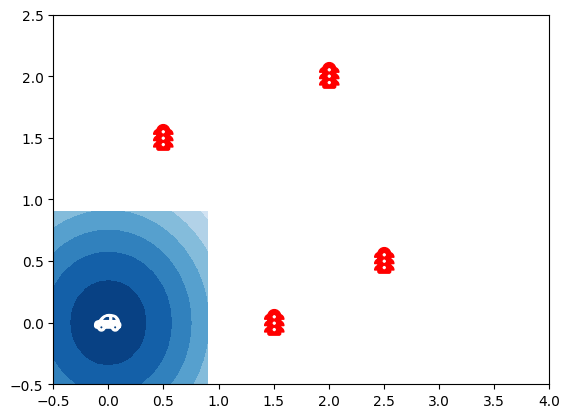

In [4]:
plot_landmarks(z)
plot_truncated_gaussian(μ0, Σ0)

## Bayes filter
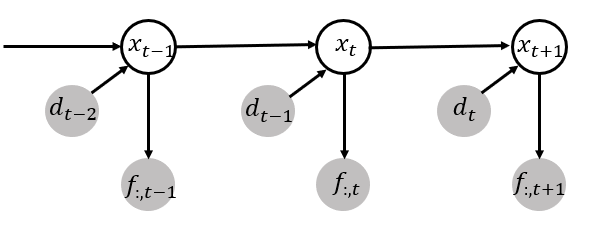
[1](#Thrun2005 "Page 25")



For our problem, $u_t = d_t$.

Let all the observation upto time $t$ be represented by $f_{1:t}$ and all the odometry inputs be denoted by $d_{1:t-1}$.
The localization problem is the estimation of the probability
$ p(x_{t} | f_{1:t}, d_{1:t-1})$.
We assume the process generating the data to be a Markovian process with state $x_t$. This means that given $x_{t-1}$, future states $x_t, x_{t+1}, \dots$ are independent of all past states $x_{t-2}, x_{t-3}, \dots$. This allows us to write the localization problem as a recursive equation
$$ p(x_t | f_{1:t}, d_{1:t-1}) = \int_{\mathcal{X}_{t-1}} p(x_t|f_t, d_{t-1}, x_{t-1})p(x_{t-1}|f_{1:t-1}, d_{1:t-2})  dx_{t-1} $$



Note that the second term inside the integral is the solution of previous localization problem. The first term is broken down into two steps, (1) the motion update or prediction step (2) measurement update step. Due to Bayes rule, we can write

$$ p(x_t|f_t, d_{t-1}, x_{t-1}) = \frac{
   p(f_t, d_{t-1}| x_t, x_{t-1})
   p(x_t | x_{t-1})
   } {
     p(f_t, d_{t-1}|x_{t-1})
     }$$

Using the independence of $f_t \perp d_{t-1} | x_t$ and $f_t \perp x_{t-1} | x_t$, and $p(f_t, d_{t-1}| x_t, x_{t-1}) = p(f_t|x_t) p(d_{t-1}|x_t, x_{t-1})$. Overall with some rearrangement, we get

$$ p(x_t|f_t, d_{t-1}, x_{t-1}) = \frac{
  p(f_t|x_t)
  p(x_{t}|d_{t-1}, x_{t-1})
   } {
     p(f_t|x_{t-1})
     }$$

This is convinient since we know the measurement model $p(f_t|x_t)$ and the motion model $p(x_t|d_{t-1}, x_{t-1})$. We assume that all observations are equally likely and hence only act as a normalizing factor:
$$p(x_t|f_t, d_{t-1}, x_{t-1}) \propto
  p(f_t|x_t)
  p(x_{t}|d_{t-1}, x_{t-1})$$

Putting this back in the Bayes recursive formulation, we get

$$ p(x_t | f_{1:t}, d_{1:t-1}) \propto p(f_t|x_t)\int_{\mathcal{X}_{t-1}} p(x_t|d_{t-1}, x_{t-1})p(x_{t-1}|f_{1:t-1}, d_{1:t-2})  dx_{t-1} $$




### Motion update or prediction step

Computing the term $\bar{\text{bel}}(x_{t-1}) = \int_{\mathcal{X}_{t-1}} p(x_t|d_{t-1}, x_{t-1})p(x_{t-1}|f_{1:t-1}, d_{1:t-2})  dx_{t-1}$

### Measurement update step

Computing the term $p(x_t | f_{1:t}, d_{1:t-1}) \propto p(f_t|x_t) \bar{\text{bel}}(x_{t-1})$

The bayes filter can be implemented in many ways, depending upon how the probability distribution is represented:

1. Particle filter
2. Histogram fitler
3. Kalman filter

## Particle filter or Sequential Importance resampling

A probability distribution can be computationally represented as samples and weights.

Given a bunch of samples $\{x_i\}_{i=1}^N$ samples sampled from a _proposal distribution_ $q(x) > 0$, if we want to compute the expected value of a function $g(x)$ over target distribution $p(x)$ [2](#MacKay1998)

$$ \mathbb{E}_{p(x)}[g(x)] = \sum_{i=1}^N \frac{g(x_i)p(x_i)}{q(x_i)} $$

### Representing $p(x_0)$ as particles

First step is to convert $x_0 \sim \mathcal{N}(\mu_0, \Sigma_0)$ as particles,
$(w_t^{(j)}, x_t^{(j)}) : w_t^{(j)} \approxeq p(x_t^{(j)} | f_{1:t}, d_{1:t-1})$.

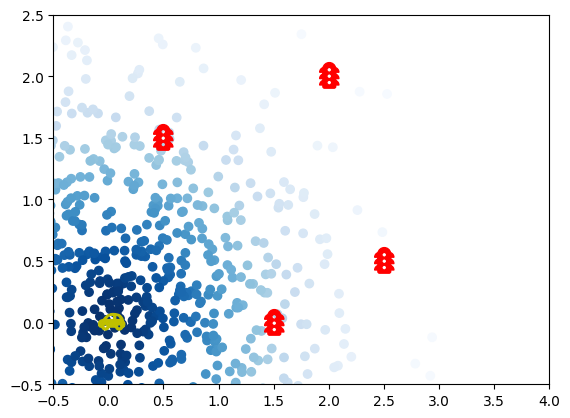

In [5]:
#@markdown Enter number of particles as $10^{logM}$
logM = 3 #@param {type: "slider", min: 1, max: 4, step: 0.5, name: "Particles "}
M = 10**logM
def initialize_particles(M, μ0, Σ0):
    x0_particles = np.random.multivariate_normal(μ0, Σ0, size=M)
    #w_particles_unnormalized = np.ones((M,1))
    w_particles_unnormalized = multivariate_normal(μ0,Σ0).pdf(x0_particles).reshape(-1, 1)
    w0_particles = w_particles_unnormalized / w_particles_unnormalized.sum()
    return w0_particles, x0_particles

w0_particles, x0_particles = initialize_particles(M, μ0, Σ0)
plot_landmarks(z)
plot_particles(w0_particles, x0_particles)

### Particle filter motion update or prediction step

$$ x_{t+1} \sim \mathcal{N}(x_t + d_t, R_t) $$

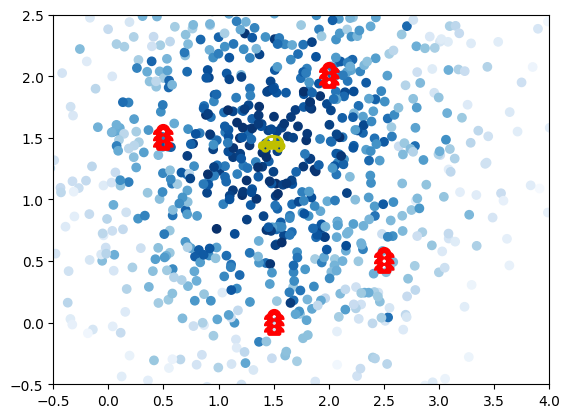

In [6]:
mean_0 = (w0_particles * x0_particles).sum(axis=0)
def motion_update(w0_particles, x0_particles, d_t):
    x1_particles = np.empty_like(x0_particles)
    for i, x0 in enumerate(x0_particles):
      x1_particles[i, :] = np.random.multivariate_normal(x0 + d_t, R)
    return w0_particles, x1_particles

w1_particles_motion, x1_particles_motion = motion_update(w0_particles, x0_particles, d[0])
plot_landmarks(z)
plot_particles(w1_particles_motion, x1_particles_motion)

### Particle filter measurement update

$$ f_{i,t} | x_t \sim \mathcal{N}(H(z_i - x_t), Q) $$
$$ p(f_t | x_t) = \prod_{i} p(f_t | x_t) $$
$$ w_{t+1}^{(j)} \propto w_{t}^{(j)} p(f_t | x_t) $$

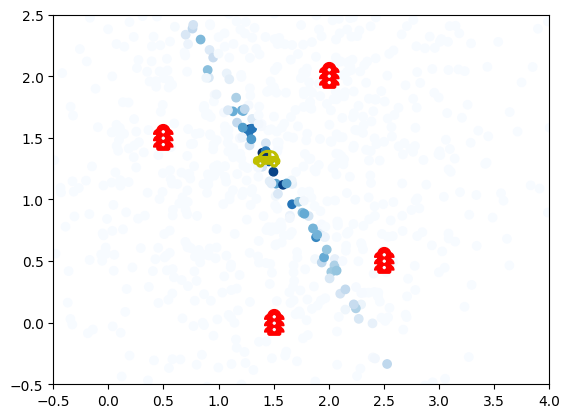

In [7]:

def measurement_update(w1_particles_motion, x1_particles_motion, visible_t, ft):
    diff_i_t = z[visible_t, np.newaxis, :] - x1_particles_motion[np.newaxis, :, :]
    VMD = diff_i_t.shape
    obs_mean = (diff_i_t.reshape(-1, VMD[-1]) @ H.T).reshape(*VMD[:2],-1)
    p_f_t = 1
    for i, fit in enumerate(ft):
        p_f_t = p_f_t * multivariate_normal(fit, Q).pdf(obs_mean[i])
        assert p_f_t.shape[0] == VMD[1]
    w1_particles_unnormalized = w0_particles * p_f_t.reshape(-1,1)
    w1_particles = w1_particles_unnormalized / w1_particles_unnormalized.sum()
    return w1_particles, x1_particles_motion

w1_particles, x1_particles = measurement_update(w1_particles_motion, x1_particles_motion, visible_all_t[1], f_i_t[1])
plot_landmarks(z)
plot_particles(w1_particles, x1_particles)

### Particle resampling step

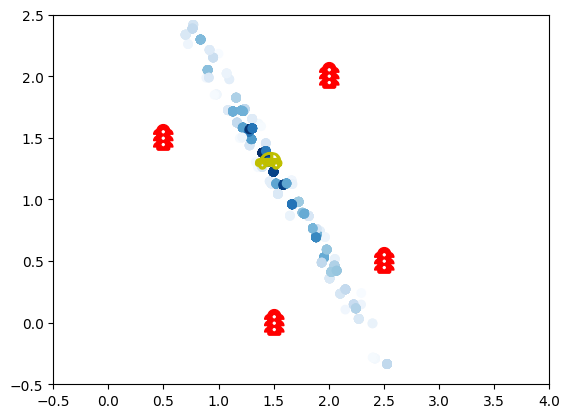

In [8]:
def resample_particles(w1_particles, x1_particles):
    effective_number = 1 / (w1_particles**2).sum()
    if effective_number > w1_particles.shape[0]/2:
      return w1_particles, x1_particles
    x1_indices = np.random.choice(w1_particles.shape[0], w1_particles.shape[0], p=w1_particles.flatten())
    x1_particles_resampled = x1_particles[x1_indices]
    w1_particles_resampled = w1_particles[x1_indices] / w1_particles[x1_indices].sum()
    return w1_particles_resampled, x1_particles_resampled

w1_particles_resampled, x1_particles_resampled = resample_particles(w1_particles, x1_particles)
plot_landmarks(z)
plot_particles(w1_particles_resampled, x1_particles_resampled)

### Full particle particle filter algorithm

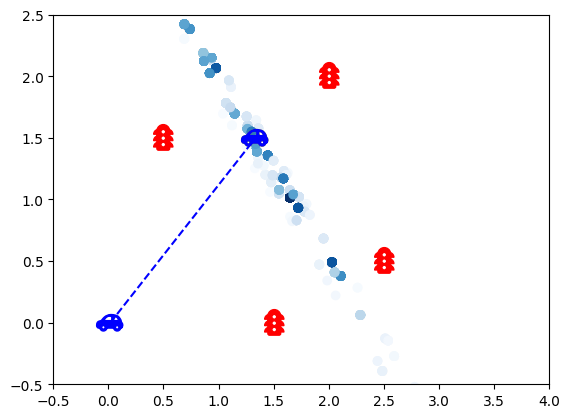

None

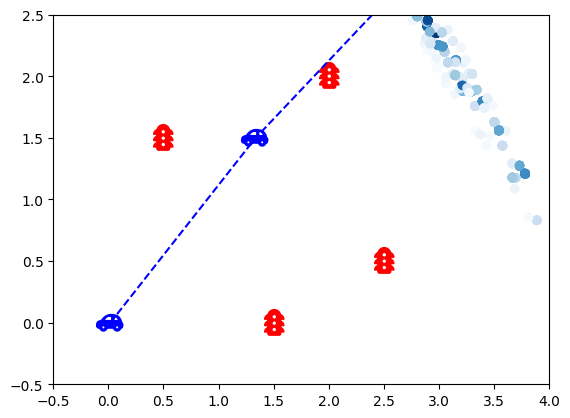

None

In [9]:
wt_particles, xt_particles = initialize_particles(M, μ0, Σ0)
means = [(wt_particles * xt_particles).sum(axis=0)]
for t in range(d.shape[0]):
  w1m, x1m = motion_update(wt_particles, xt_particles, d[t])
  w1, x1 = measurement_update(w1m, x1m, visible_all_t[t+1], f_i_t[t+1])
  wt_particles, xt_particles = resample_particles(w1, x1)
  plot_landmarks(z)
  plot_particles(wt_particles, xt_particles)
  means.append((wt_particles * xt_particles).sum(axis=0))
  mean_np = np.array(means)
  plt.plot(mean_np[:, 0], mean_np[:, 1], markersize=20, marker=mplcar, linestyle='--', color='b')
  display(plt.show())


## Kalman Filter

Kalman filter assumes Gaussian distributions and linear measurement and motion models.

Assume motion model

$$ x_{t+1} = A_t x_t + B_t d_t + \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, R_t)$$

and measurement model
$$ f_t = H_t x_t + \eta_t, \quad \eta_t \sim \mathcal{N}(0, Q_t)$$

### Kalman filter model for the simple Localization problem

The measurement model in simple localization problem is linear when written as $f_{i,t} = H(z_i - x_t) + \eta_t$. It is affine. Moreover, it needs to be stacked to compute $f_t$ for all $i$ in a single matrix multiplication.
Let the new state be defined as $\bar{x}_t = [x_t^\top, 1]^\top$. Then the motion model becomes,

$$ \bar{x}_{t+1} = \bar{x}_t + \begin{bmatrix}1 & 0\\ 0 & 1\\ 0 & 0 \end{bmatrix} d_t + \bar{\epsilon}_t, \quad \bar{\epsilon}_t \sim \mathcal{N}(0, \bar{R}_t)$$

where

$$ \bar{R}_t = \begin{bmatrix} R_t & 0 \\ 0 & \delta
\end{bmatrix}$$. $\delta = 10^{-6}$.

The measurement model becomes,

$$ \begin{bmatrix} f_{1,t}
\\
f_{2,t}
\\
\vdots
\\
f_{N,t}
\end{bmatrix}
=
\underbrace{
\begin{bmatrix}
-H & Hz_1 \\
-H & Hz_2 \\
\vdots & \vdots \\
-H & Hz_N
\end{bmatrix}}_{\bar{H}_t}
\bar{x}_t
+
\underbrace{
\begin{bmatrix} \eta_1 \\
\eta_2 \\
\vdots \\
\eta_N
\end{bmatrix}
}_{\bar{\eta}}$$,

$$\bar{\eta} \sim \mathcal{N}\left(0,
\begin{bmatrix} Q & 0 & \dots & 0 \\
0 & Q & \dots & 0 \\
\vdots & \vdots & \dots & \vdots \\
0 & 0 & \dots & Q
\end{bmatrix}\right)$$


Hence, the Kalman filter constants for the simple localization problem are:

$$ \bar{A}_t = I_{3\times 3},
 \bar{B}_t = I_{3\times 2},
 \bar{H}_t =
\begin{bmatrix}
-H & Hz_1 \\
-H & Hz_2 \\
\vdots & \vdots \\
-H & Hz_N
\end{bmatrix},
\bar{Q}_t = \begin{bmatrix} Q & 0 & \dots & 0 \\
0 & Q & \dots & 0 \\
\vdots & \vdots & \dots & \vdots \\
0 & 0 & \dots & Q
\end{bmatrix},
\bar{R}_t = \begin{bmatrix}R & 0 \\ 0 & \delta \end{bmatrix} $$



In [10]:
mu_0 = np.hstack((μ0, 1))
sigma_0 = np.eye(mu_0.shape[0])
sigma_0[:-1, :-1] = Σ0

D = μ0.shape[0]
Abart = np.eye(D+1)
Bbart = np.zeros((D+1,D))
Bbart[:D,:D] = np.eye(D)

def Hbart_create(H, z, visible_t):
  Hstacked = np.repeat(H, len(visible_t), axis=0)
  Hzis = []
  for i, lid in enumerate(visible_t):
    Hzis.append(H @ z[lid])
  return np.hstack((-Hstacked, np.vstack(Hzis)))

Rbart = np.eye(D+1) * 1e-6
Rbart[:D, :D] = R

def Qbart_create(Q, visible_t):
  from scipy.linalg import block_diag
  return block_diag(*([Q]*len(visible_t)))


### Motion or prediction step
[Thrun et al. 2005](#Thrun2005)
[marginal of a gaussian](https://people.eecs.berkeley.edu/~jordan/courses/260-spring10/other-readings/chapter13.pdf)
[marginal of a gaussian without schur complement](https://stats.stackexchange.com/questions/30588/deriving-the-conditional-distributions-of-a-multivariate-normal-distribution)
[kalman filter using marginal](https://users.aalto.fi/~ssarkka/course_k2016/handout3.pdf)

$\newcommand{\bbE}{\mathbb{E}}$
$\newcommand{\bfx}{\mathbf{x}}$
$\newcommand{\calN}{\mathcal{N}}$
$$ \bbE[\bfx_{t}] = \bbE[A\bfx_{t-1}+Bd_{t-1}]$$
$$ \bar{\mu}_{t} = A\mu_{t-1} + B d_{t-1}$$
$$ \bbE[(\bfx_{t} - \mu_{t}) (\bfx_t - \mu_{t})^\top] = \bbE[(A(\bfx_{t-1}-\mu_{t-1})+\epsilon_{t-1})(A(\bfx_{t-1}-\mu_{t-1}) + \epsilon_{t-1})^\top]$$
$$ = \bar{\Sigma}_{t} = A \Sigma_{t-1} A^\top + R_{t-1} $$

$$p(x_t| f_{1:t-1}, d_{1:t-1}) = \int_{\mathcal{X}_{t-1}} p(x_t|d_{t-1}, x_{t-1})p(x_{t-1}|f_{1:t-1}, d_{1:t-2})  dx_{t-1} = \calN(x_t; \bar{\mu}_t, \bar\Sigma_t)$$

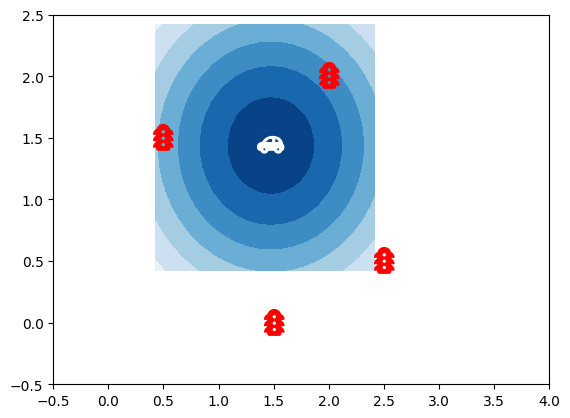

In [11]:
def motion_update_kf(mu_t, sigma_t, d_t, At, Bt, Rt):
  mu_tp1 = At @ mu_t + Bt @ d_t
  sigma_tp1 = At @ sigma_t @ At.T + Rt
  return mu_tp1, sigma_tp1

mu_1_motion, sigma_1_motion = motion_update_kf(mu_0, sigma_0, d[0], Abart, Bbart, Rbart)
plot_truncated_gaussian(mu_1_motion[:D], sigma_1_motion[:D, :D])
plot_landmarks(z)

### Measurement update step
  [Thrun et al. 2005](#Thrun2005)

\begin{align}
\calN(x_t; \mu_t, \Sigma_t) &= p(x_t|f_{1:t}, d_{1:t-1}) \propto p(f_{t}|x_t) p(x_t|f_{1:t-1}, d_{1:t-1})
\\
\calN(x_t; \mu_t, \Sigma_t) &=\calN(f_t; Hx_t, Q)\calN(x_t; \bar\mu_t, \bar\Sigma_t)
\end{align}
We need to expand the two Gaussian distributions, multiply them and collect the terms corresponding to $x_t$. Recall that,
\begin{align}
\calN(x_t; \mu_t, \Sigma_t) &= \det(2\pi \Sigma_t)^{-1/2}
 \exp\left(-\frac{1}{2}(x_t - \mu_t)^\top \Sigma_t^{-1} (x_t - \mu_t)\right),\\
\calN(f_t; Hx_t, Q) &= \det(2\pi Q)^{-1/2}
 \exp\left(-\frac{1}{2}(f_t - Hx_t)^\top Q^{-1} (f_t - Hx_t)\right),\\
\text{and }
\calN(x_t; \bar\mu_t, \bar\Sigma_t) &= \det(2\pi \bar\Sigma_t)^{-1/2}
 \exp\left(-\frac{1}{2}(x_t - \bar\mu_t)^\top \bar\Sigma_t^{-1} (x_t - \bar\mu_t)\right).
\end{align}
When you multiple the two distributions, the terms inside the exponentials get added. Focusing only on the exponential terms without the common factor $-\frac{1}{2}$, we get,

$$
(x_t - \mu_t)^\top\Sigma_t^{-1}(x_t - \mu_t) = (f_t - Hx_t)^\top Q^{-1} (f_t - Hx_t) + (x_t - \bar\mu_t)^\top \bar\Sigma_t^{-1} (x_t - \bar\mu_t).
$$
Compare the quadratic terms and linear terms for $x_t$ on both sides,
\begin{align}
\Sigma_t^{-1} &= H^\top Q^{-1}H + \bar\Sigma_t^{-1}\\
\Sigma_t^{-1}\mu_t &= H^\top Q^{-1} f_t + \bar\Sigma_t^{-1} \bar\mu_t
\end{align}

This is the solution. We can rewrite it in many ways. Let us rewrite $\mu_t$ in a way that it is more commonly written.

---

\begin{align}
\Sigma_t^{-1}\mu_t &= H^\top Q^{-1} f_t + \bar\Sigma_t^{-1} \bar\mu_t\\
\implies
\Sigma_t^{-1}\mu_t &= H^\top Q^{-1} f_t - H^\top Q^{-1}H\bar\mu_t + H^\top Q^{-1}H\bar\mu_t + \bar\Sigma_t^{-1} \bar\mu_t\\
\implies
\Sigma_t^{-1}\mu_t &= H^\top Q^{-1} (f_t - H\bar\mu_t) + \underbrace{(H^\top Q^{-1}Ht + \bar\Sigma_t^{-1})}_{\Sigma_t^{-1}} \bar\mu_t \\
\implies
\mu_t &= \underbrace{\Sigma_t H^\top Q^{-1}}_{K_t} (f_t - H\bar\mu_t) + \bar\mu_t.
\end{align}

Here $K_t = \Sigma_t H^\top Q^{-1} = (H^\top Q^{-1}H + \bar\Sigma_t^{-1})^{-1} H^\top Q^{-1}$ is called the Kalman gain, the factor by which measurement error $f_t-H\bar\mu_t$ shifts the motion mean $\bar\mu_t$.


---

If the state matrix $\bar\Sigma_t$ is much higher bigger than the measurement matrix $H\bar\Sigma_tH^\top$, then we want to take  the inverse of the smaller matrix. We can use the Woodberry inversion lemma to rewrite the Kalman gain. The inversion lemma states that for appropriately sized matrices, A, B, C, D, and $A$ and $D$ being invertible,
$$ (D + CA^{-1}B)^{-1} = D^{-1} - D^{-1}C(A+BD^{-1}C)^{-1}BD^{-1}.$$
Applying this to $\Sigma_t = (H^\top Q^{-1}H + \bar\Sigma_t^{-1})^{-1}$, we get
\begin{align}
  \Sigma_t &= \bar\Sigma_t - \bar\Sigma_t H^\top(Q + H\bar\Sigma_t H^\top)^{-1}H \bar\Sigma_t \\
  &= (I - \underbrace{\bar\Sigma_t H^\top(Q + H\bar\Sigma_t H^\top)^{-1}}_{K'_t}H)\bar\Sigma_t.
\end{align}



In fact, $K'_t = K_t$,

\begin{align}
K_t &= \Sigma_t H^\top Q^{-1} \\
&= \Sigma_t H^\top Q^{-1} (Q + H\bar\Sigma_t H^\top)(Q + H\bar\Sigma_t H^\top)^{-1}  \\
&=  \Sigma_t ( H^\top  + H^\top Q^{-1} H\bar\Sigma_t H^\top)(Q + H\bar\Sigma_t H^\top)^{-1} \\
&=  \Sigma_t (\bar\Sigma_t^{-1} \bar\Sigma_t H^\top  + H^\top Q^{-1} H\bar\Sigma_t H^\top)(Q + H\bar\Sigma_t H^\top)^{-1} \\
&=  \Sigma_t (\bar\Sigma_t^{-1}  + H^\top Q^{-1} H)\bar\Sigma_t H^\top(Q + H\bar\Sigma_t H^\top)^{-1} \\
&=  \Sigma_t \Sigma_t^{-1}\bar\Sigma_t H^\top(Q + H\bar\Sigma_t H^\top)^{-1} \\
&= \bar\Sigma_t H^\top(Q + H\bar\Sigma_t H^\top)^{-1} \\
&= K'_t
\end{align}
  


 ---

  $$ K_{t} = \bar{\Sigma}_{t}H_t^\top(H_t \bar{\Sigma}_{t+1}H_t^\top + Q_t)^{-1}$$
  $$ \mu_{t} = \bar{\mu}_{t} + K_{t}(f_t - H_t\mu_{t})$$
  $$ \Sigma_{t} = (I - K_{t}H_t) \bar{\Sigma}_{t} $$


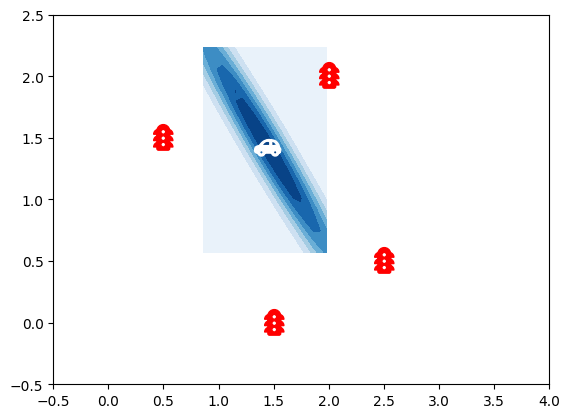

In [12]:
def measurement_update_kf(mu_t, sigma_t, f_is, Hbart, Qbart):
  diff = f_is - Hbart @ mu_t
  HSigmaH_plus_Q = Hbart @ sigma_t @ Hbart.T + Qbart
  mu_tp1 = mu_t + sigma_t @ Hbart.T @ np.linalg.solve(HSigmaH_plus_Q, diff)
  I = np.eye(mu_t.shape[0])
  sigma_tp1 = (I - sigma_t @ Hbart.T @ np.linalg.solve(HSigmaH_plus_Q, Hbart)) @ sigma_t
  return mu_tp1, sigma_tp1

f_is = f_i_t[1].flatten()
mu_1, sigma_1 = measurement_update_kf(mu_1_motion, sigma_1_motion, f_is, Hbart_create(H, z, visible_all_t[1]), Qbart_create(Q, visible_all_t[1]))

plot_truncated_gaussian(mu_1[:D], sigma_1[:D, :D])
plot_landmarks(z)

### Full Kalman Filter algorithm

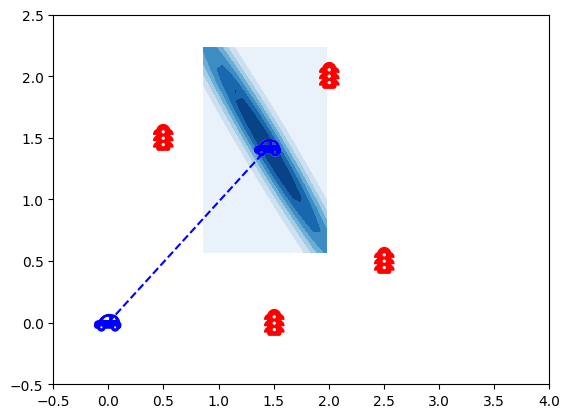

None

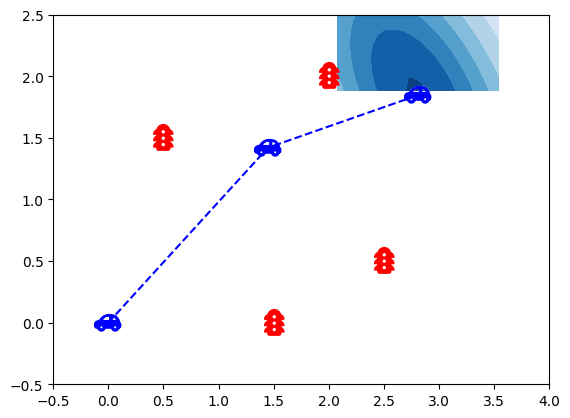

None

In [13]:
mu_t, sigma_t = μ0, Σ0
means = [mu_t]
for t in range(d.shape[0]):
  mu_1_motion, sigma_1_motion = motion_update_kf(mu_0, sigma_0, d[t], Abart, Bbart, Rbart)
  f_is = f_i_t[t+1].flatten()
  mu_t, sigma_t = measurement_update_kf(mu_1_motion, sigma_1_motion, f_is,
                                      Hbart_create(H, z, visible_all_t[t+1]),
                                       Qbart_create(Q, visible_all_t[t+1]))
  plot_truncated_gaussian(mu_t[:D], sigma_t[:D, :D])
  plot_landmarks(z)
  means.append(mu_t[:D])
  mean_np = np.hstack(means).reshape(-1, D)
  plt.plot(mean_np[:, 0], mean_np[:, 1], markersize=20, marker=mplcar, linestyle='--', color='b')
  display(plt.show())

<span id="MacKay1998">[MacKay1998]: MacKay, David JC. "Introduction to monte carlo methods." Learning in graphical models. Springer, Dordrecht, 1998. 175-204</span>

<span id="Thrun2005">[Thrun2005]: Thrun, Sebastian, Wolfram Burgard, and Dieter Fox. Probabilistic robotics. MIT press, 2005</span>

<span id="mackay1998">